# 06 — Intro to Least Squares

## Purpose

This notebook explains least squares using a small line-fitting example.

The aim is to make precise what we mean by a **best-fitting line**:

> the line whose predictions have the smallest total squared vertical error from the observed data points.

By the end, you should be able to explain:

- what a **candidate line** is
- what a **residual** is, including its sign
- why least squares uses **squared** residuals
- how the line-fitting problem becomes a matrix problem
- why the matrix equation usually has no exact solution
- how this connects back to projection


## Imports and helpers


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def setup_plot(title, xlim=(0.5, 4.5), ylim=(1.5, 4.25), figsize=(5.5, 4)):
    '''Create a small, consistent plot for this notebook.'''
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    return fig, ax


def predict_line(x_values, slope, intercept):
    '''Return predicted y-values for y = mx + c.'''
    return slope * x_values + intercept


def sum_squared_residuals(actual, predicted):
    '''Return the sum of squared residuals for actual and predicted values.'''
    residuals = actual - predicted
    return np.sum(residuals ** 2)


## A simple fitting problem

Suppose we have four observed points:

$$
(1, 2),\ (2, 2.5),\ (3, 3.5),\ (4, 3.8)
$$

They do not sit perfectly on a straight line.

But we can still ask:

> Which straight line fits these points reasonably well?


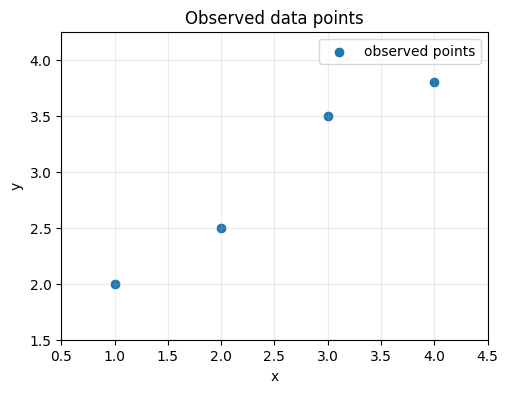

In [2]:
x = np.array([1, 2, 3, 4])
y = np.array([2.0, 2.5, 3.5, 3.8])

fig, ax = setup_plot("Observed data points")
ax.scatter(x, y, label="observed points")
ax.legend()
plt.show()


## A candidate line

We can generate a **candidate line** for any chosen values of $m$ and $c$.

At this stage, we are not claiming the line is best. We are just choosing one possible line so that we can see how predictions and errors work.


In [3]:
candidate_m = 0.7
candidate_c = 1.2

candidate_y = predict_line(x, candidate_m, candidate_c)

print ("x:              ", x)
print("actual y:       ", y)
print("candidate y_hat:", candidate_y)


x:               [1 2 3 4]
actual y:        [2.  2.5 3.5 3.8]
candidate y_hat: [1.9 2.6 3.3 4. ]


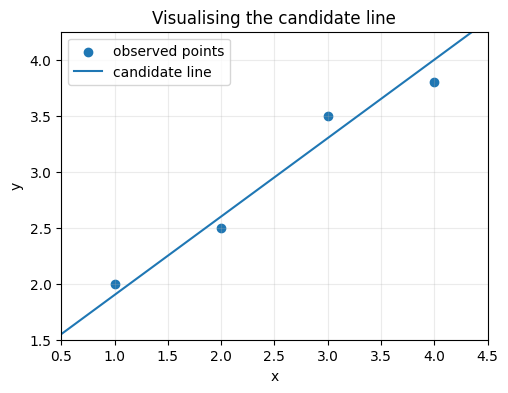

In [4]:
line_x = np.linspace(0.5, 4.5, 100)
line_y = predict_line(line_x, candidate_m, candidate_c)

fig, ax = setup_plot("Visualising the candidate line")
ax.scatter(x, y, label="observed points")
ax.plot(line_x, line_y, label="candidate line")
ax.legend()
plt.show()


## Residuals

For one data point, a **residual** is the difference between the actual value and the predicted value:

$$
r_i = y_i - \hat{y}_i
$$

The subscript $i$ means “for data point $i$”.

So:

- $r_i > 0$ means the observed point is **above** the candidate line
- $r_i < 0$ means the observed point is **below** the candidate line
- $r_i = 0$ means the candidate line hits that point exactly

For the whole dataset, we can collect all the residuals into one residual vector:

$$
r = y - \hat{y}
$$

The sign matters while we are understanding the residuals, even though least squares will soon square them.


In [5]:
candidate_residuals = y - candidate_y

print("candidate residuals:", candidate_residuals)


candidate residuals: [ 0.1 -0.1  0.2 -0.2]


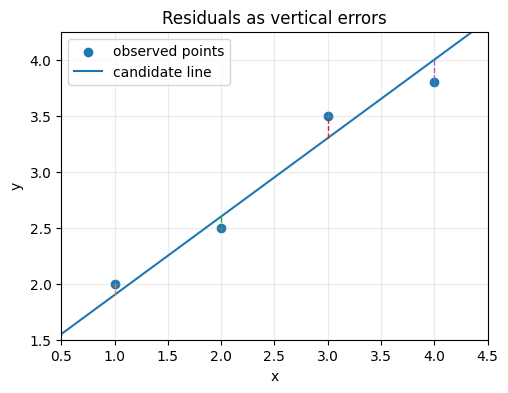

In [6]:
fig, ax = setup_plot("Residuals as vertical errors")
ax.scatter(x, y, label="observed points")
ax.plot(line_x, line_y, label="candidate line")

# Draw one vertical residual per observed point.
for xi, actual, predicted in zip(x, y, candidate_y):
    ax.plot([xi, xi], [predicted, actual], linestyle="--", linewidth=1)

ax.legend()
plt.show()


The dashed lines show the vertical differences between the candidate line and the observed data points.

They are **vertical** because this model is trying to predict $y$ from $x$.

That is slightly different from asking for the shortest geometric distance from a point to the drawn line. In ordinary line fitting for prediction, we normally hold each observed $x$ fixed and ask:

> how far away was the predicted $y$ from the actual $y$?

Later, the matrix version will describe this as choosing a reachable prediction vector as close as possible to the actual target vector.


## Why square the residuals?

If we simply added the residuals, positive and negative errors could cancel out.

For example:

$$
1 + (-1) = 0
$$

That would be a terrible error score, because two wrong predictions could look perfect.

Least squares avoids cancellation by squaring each residual:

$$
\sum_i r_i^2
$$

or, using $r_i = y_i - \hat{y}_i$:

$$
\sum_i (y_i - \hat{y}_i)^2
$$

Squaring does two useful things:

- negative and positive residuals both become positive
- larger errors are penalised more heavily

This is not the only possible definition of “best”. For example, some approaches minimise absolute errors instead:

$$
\sum_i |r_i|
$$

Least squares is popular because squared residuals lead to a smooth, convenient problem with a strong geometric interpretation. The downside is that large outliers can have a big effect, because squaring makes large residuals much larger.


In [7]:
candidate_ssr = sum_squared_residuals(y, candidate_y)

print("candidate residuals:       ", candidate_residuals)
print("candidate squared residuals:", candidate_residuals ** 2)
print("candidate sum of squared residuals:", candidate_ssr)


candidate residuals:        [ 0.1 -0.1  0.2 -0.2]
candidate squared residuals: [0.01 0.01 0.04 0.04]
candidate sum of squared residuals: 0.10000000000000009


## Why not just try every possible line?

In principle, we could try many candidate lines and keep the one with the smallest sum of squared residuals.

But there are infinitely many possible values of $m$ and $c$.

A small brute-force grid can help us understand the idea, but it is not how we want to solve real problems.


In [8]:
# This is only a learning demonstration, not the real method.
candidate_slopes = np.linspace(0.0, 1.2, 7)
candidate_intercepts = np.linspace(0.0, 2.0, 6)

best_score = np.inf
best_candidate = None

for m in candidate_slopes:
    for c in candidate_intercepts:
        predicted = predict_line(x, m, c)
        score = sum_squared_residuals(y, predicted)

        if score < best_score:
            best_score = score
            best_candidate = (m, c)

print("best grid candidate (m, c):", best_candidate)
print("best grid score:", best_score)


best grid candidate (m, c): (np.float64(0.6), np.float64(1.6))
best grid score: 0.18000000000000005


The grid search gives only the best line among the lines we happened to try.

Least squares gives a direct way to find the best parameters without comparing a huge list of guesses.


## Let NumPy find the least-squares line

First, we can use `np.polyfit` as a convenient line-fitting tool.

With degree `1`, `np.polyfit` fits a line:

$$
\hat{y} = mx + c
$$


In [9]:
best_m, best_c = np.polyfit(x, y, deg=1)

best_y = predict_line(x, best_m, best_c)
best_residuals = y - best_y
best_ssr = sum_squared_residuals(y, best_y)

print("best slope m:     ", best_m)
print("best intercept c: ", best_c)
print("best predicted y: ", best_y)
print("best residuals:   ", best_residuals)
print("best sum of squared residuals:", best_ssr)


best slope m:      0.6399999999999998
best intercept c:  1.3500000000000008
best predicted y:  [1.99 2.63 3.27 3.91]
best residuals:    [ 0.01 -0.13  0.23 -0.11]
best sum of squared residuals: 0.08199999999999993


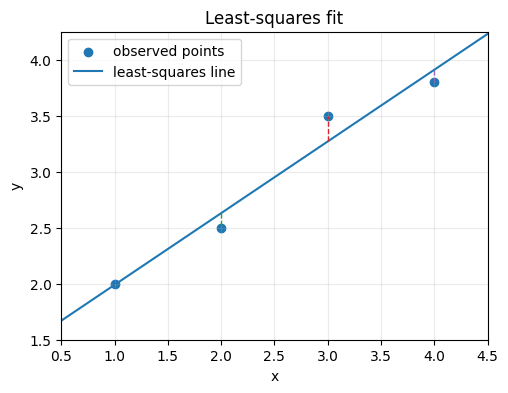

In [10]:
best_line_y = predict_line(line_x, best_m, best_c)

fig, ax = setup_plot("Least-squares fit")
ax.scatter(x, y, label="observed points")
ax.plot(line_x, best_line_y, label="least-squares line")

for xi, actual, predicted in zip(x, y, best_y):
    ax.plot([xi, xi], [predicted, actual], linestyle="--", linewidth=1)

ax.legend()
plt.show()


The least-squares line has a smaller sum of squared residuals than the earlier candidate line.

That is what **best** means in this notebook:

> best = smallest sum of squared residuals


## Matrix view of the same problem

Now we will write the same line-fitting problem as a matrix equation.

For one data point, the prediction is:

$$
\hat{y}_i = mx_i + c
$$

The same calculation can be written as a dot product:

$$
\hat{y}_i =
\begin{bmatrix}
x_i & 1
\end{bmatrix}
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

because:

$$
\begin{bmatrix}
x_i & 1
\end{bmatrix}
\begin{bmatrix}
m \\
c
\end{bmatrix}
=
x_i m + 1c
=
mx_i + c
$$

The $1$ is there because the intercept $c$ is added once for every prediction.


For our four observed $x$-values:

$$
x = 1,\ 2,\ 3,\ 4
$$

the four prediction equations are:

$$
\hat{y}_1 = 1m + c
$$

$$
\hat{y}_2 = 2m + c
$$

$$
\hat{y}_3 = 3m + c
$$

$$
\hat{y}_4 = 4m + c
$$

Stacking these equations gives:

$$
\begin{bmatrix}
\hat{y}_1 \\
\hat{y}_2 \\
\hat{y}_3 \\
\hat{y}_4
\end{bmatrix}
=
\begin{bmatrix}
1 & 1 \\
2 & 1 \\
3 & 1 \\
4 & 1
\end{bmatrix}
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

More compactly:

$$
\hat{y} = X\beta
$$

where:

$$
X =
\begin{bmatrix}
1 & 1 \\
2 & 1 \\
3 & 1 \\
4 & 1
\end{bmatrix}
$$

and:

$$
\beta =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

Here, $\beta$ is just a compact name for the parameters the model is trying to learn.


### The design matrix

The matrix $X$ is called the **design matrix**.

In this example:

- the first column contains the observed $x$-values
- the second column contains ones, so the intercept is included in every prediction

The first column is not special counting. It is just the observed $x$ data.

If the observed $x$-values were:

$$
0.5,\ 2.0,\ 2.7,\ 10.0
$$

then the first column of the design matrix would be those values instead.


In [11]:
# Four observed x-values.
example_x = np.array([0.5, 2.0, 2.7, 10.0])

# One intercept value is needed for each observed x-value.
intercept_column = np.ones_like(example_x)

# Put the x column and intercept column side by side.
example_X = np.column_stack([example_x, intercept_column])

print(example_X)


[[ 0.5  1. ]
 [ 2.   1. ]
 [ 2.7  1. ]
 [10.   1. ]]


Two small NumPy details:

- `np.ones_like(x)` creates an array of ones with the same shape as `x`
- `np.column_stack([...])` combines one-dimensional arrays as columns

Each row of $X$ corresponds to one observed $x$-value.

For example, the row:

$$
\begin{bmatrix}
3 & 1
\end{bmatrix}
$$

means:

$$
3m + 1c
$$

which is the original line equation evaluated at $x = 3$.


In [13]:
beta = np.array([best_m, best_c])
intercept_column = np.ones_like(x)

# Put the x column and intercept column side by side.
X = np.column_stack([x, intercept_column])
predictions_from_matrix = X @ beta

print("X @ beta:       ", predictions_from_matrix)
print("best predicted y:", best_y)


X @ beta:        [1.99 2.63 3.27 3.91]
best predicted y: [1.99 2.63 3.27 3.91]


The matrix calculation gives the same predictions as the earlier line calculation.

So these are two views of the same thing:

$$
\hat{y} = mx + c
$$

and:

$$
\hat{y} = X\beta
$$


## Why there is not usually an exact solve

If the model could fit the points exactly, we would have:

$$
X\beta = y
$$

For our four data points, that would require the same $m$ and $c$ to satisfy all four equations:

$$
1m + c = 2.0
$$

$$
2m + c = 2.5
$$

$$
3m + c = 3.5
$$

$$
4m + c = 3.8
$$

There are four equations but only two unknowns.

That does not automatically prove there is no exact solution. If all four points sit perfectly on one straight line, the equations can still be consistent.

But for noisy or imperfect data, these equations are usually inconsistent: no single line can satisfy them all exactly.


### Can we identify that there is no exact solution?

Yes.

One linear-algebra way is to compare the rank of $X$ with the rank of the augmented matrix $[X \mid y]$.

If:

$$
\operatorname{rank}(X) \ne \operatorname{rank}([X \mid y])
$$

then the exact system:

$$
X\beta = y
$$

has no solution.

You do not need to master this test yet, but it is useful to know that “no exact solution” is not just a guess.


In [ ]:
augmented = np.column_stack([X, y])

rank_X = np.linalg.matrix_rank(X)
rank_augmented = np.linalg.matrix_rank(augmented)

print("rank of X:       ", rank_X)
print("rank of [X | y]: ", rank_augmented)

if rank_X == rank_augmented:
    print("An exact solution exists.")
else:
    print("No exact solution exists.")


Another practical check is to fit the least-squares line and see whether the residuals are all essentially zero.

Here they are not.


In [ ]:
print("least-squares residuals:", best_residuals)
print("residual norm:", np.linalg.norm(best_residuals))


## Solving with `np.linalg.lstsq`

`np.polyfit` was convenient because this example is a polynomial line-fitting problem.

More generally, NumPy can solve the matrix least-squares problem directly:

$$
X\beta \approx y
$$

This means:

> find the parameter vector $\beta$ where $X\beta$ gets as close as possible to $y$.

In this notebook:

$$
\beta =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

so the first value in $\beta$ is the slope, and the second value is the intercept.


In [ ]:
beta_lstsq, residuals_sum, rank, singular_values = np.linalg.lstsq(X, y, rcond=None)

print("beta from lstsq:", beta_lstsq)
print("slope:          ", beta_lstsq[0])
print("intercept:      ", beta_lstsq[1])


`np.linalg.lstsq` returns several values.

For now, the important one is:

```text
beta_lstsq
```

That contains the least-squares parameters.

The other values are diagnostics:

- `residuals_sum` relates to the squared residual error
- `rank` tells us the rank of the design matrix
- `singular_values` are useful in deeper numerical linear algebra

We do not need to unpack those fully yet.


In [ ]:
predicted_from_lstsq = X @ beta_lstsq
residuals_from_lstsq = y - predicted_from_lstsq

print("predicted from lstsq:", predicted_from_lstsq)
print("residuals from lstsq:", residuals_from_lstsq)
print("sum of squared residuals:", np.sum(residuals_from_lstsq ** 2))


## Connection back to projection

This is the geometric idea behind least squares.

The model can only produce prediction vectors of this form:

$$
X\beta
$$

As $\beta$ changes, $X\beta$ moves around inside the **column space** of $X$.

The **column space** of $X$ means:

> all possible vectors you can make by combining the columns of $X$

In this line-fitting problem, the columns of $X$ are:

$$
\begin{bmatrix}
1 \\
2 \\
3 \\
4
\end{bmatrix}
\quad
\text{and}
\quad
\begin{bmatrix}
1 \\
1 \\
1 \\
1
\end{bmatrix}
$$

So every possible prediction vector has the form:

$$
m
\begin{bmatrix}
1 \\
2 \\
3 \\
4
\end{bmatrix}
+
c
\begin{bmatrix}
1 \\
1 \\
1 \\
1
\end{bmatrix}
$$

That is the reachable space for this model.


The actual target vector is:

$$
y =
\begin{bmatrix}
2.0 \\
2.5 \\
3.5 \\
3.8
\end{bmatrix}
$$

Usually, $y$ is not exactly in the column space of $X$.

So least squares chooses the reachable prediction vector closest to $y$:

$$
\hat{y} = X\hat{\beta}
$$

Then the leftover residual vector is:

$$
r = y - \hat{y}
$$

The key decomposition is:

$$
y = \hat{y} + r
$$

or, using the matrix form:

$$
y = X\hat{\beta} + r
$$

In plain English:

> actual target vector = reachable prediction vector + leftover residual vector


In [ ]:
y_hat = X @ beta_lstsq
r = y - y_hat

print("target y:        ", y)
print("prediction y_hat:", y_hat)
print("residual r:      ", r)
print("check y_hat + r: ", y_hat + r)


For the least-squares solution, the residual vector is perpendicular to the column space of $X$.

One way to check this is to take dot products between the residual vector and each column of $X$.

If the residual is perpendicular to each column, those dot products should be close to zero:

$$
X^T r \approx 0
$$

This is the projection idea:

> least squares projects the target vector onto the reachable prediction space.


In [ ]:
print("X.T @ r:", X.T @ r)


The values are extremely close to zero. The tiny non-zero-looking parts are just floating-point rounding.

This gives the geometric picture:

$$
y = X\hat{\beta} + r
$$

where:

- $X\hat{\beta}$ is the closest reachable prediction vector
- $r$ is the leftover error vector
- $r$ is perpendicular to the reachable prediction space


## Summary

Least squares is useful when an exact fit is not possible.

In this notebook, we fitted a line to a small set of points.

A **candidate line** is one possible choice of parameters $m$ and $c$.

For one data point, the residual is:

$$
r_i = y_i - \hat{y}_i
$$

For all data points together, the residual vector is:

$$
r = y - \hat{y}
$$

Least squares defines the best line as the line that minimises:

$$
\sum_i r_i^2
$$

or equivalently:

$$
\sum_i (y_i - \hat{y}_i)^2
$$

The same line-fitting problem can be written in matrix form:

$$
\hat{y} = X\beta
$$

where:

- $X$ is the design matrix
- $\beta$ contains the parameters being learned
- in this example, $\beta = [m,\ c]^T$

Usually, the exact system:

$$
X\beta = y
$$

has no solution.

So least squares solves the approximate problem:

$$
X\beta \approx y
$$

The geometric idea is:

$$
y = X\hat{\beta} + r
$$

In words:

> actual target vector = reachable prediction vector + leftover residual vector

That is the bridge back to projection.
